# **Estrategia de partición de datos**

## **Establecer conjunto de train, validación y test**

Con el fin de evaluar el desempeño predictivo de los modelos de series de tiempo, se realizó una partición de los datos en tres subconjuntos: entrenamiento (train), validación (validation) y prueba (test), respetando en todo momento la estructura temporal de la serie.

En primer lugar, las series correspondientes a climas frío y cálido fueron ajustadas a una frecuencia horaria utilizando el método asfreq('h'). Posteriormente, se aplicó una interpolación lineal para completar posibles valores faltantes y garantizar la continuidad temporal de la serie.

Dado que el objetivo del estudio es realizar predicciones de corto plazo, se definió un horizonte de predicción de 24 horas. Esta decisión se encuentra respaldada por la literatura, la cual señala que los horizontes de corto plazo (menores o iguales a un día) son ampliamente utilizados en el análisis de la demanda energética, especialmente en enfoques basados en métodos estadísticos y de aprendizaje automático. Asimismo, se ha documentado que las técnicas de modelación presentan un mejor desempeño en este tipo de horizontes debido a la fuerte dependencia temporal y la disponibilidad de datos de alta frecuencia.
Los puntos de corte utilizados fueron el 1 de junio de 2025 para el inicio del conjunto de validación y el 1 de diciembre de 2025 para el conjunto de prueba.

Esta estrategia garantiza que los modelos sean entrenados y evaluados bajo un esquema estrictamente temporal, replicando un escenario real de predicción donde únicamente se dispone de información pasada para anticipar valores futuros.

In [ ]:
serie_frio = serie_frio.asfreq('h').interpolate(method='linear')
serie_calor = serie_calor.asfreq('h').interpolate(method='linear')

H = 24

# Crear DataFrames auxiliares
df_frio = serie_frio.to_frame(name='Value')
df_calor = serie_calor.to_frame(name='Value')

# Horizonte
df_frio['horizon_end'] = df_frio.index + pd.Timedelta(hours=H)
df_calor['horizon_end'] = df_calor.index + pd.Timedelta(hours=H)

# Cortes (ajústalos si ya los definiste antes)
val_start  = pd.Timestamp('2025-06-01 00:00:00')
test_start = pd.Timestamp('2025-12-01 00:00:00')

# -----------------------
# FRÍO
# -----------------------
train_frio = df_frio[df_frio['horizon_end'] <= val_start]

val_frio = df_frio[(df_frio['horizon_end'] > val_start) &
                   (df_frio['horizon_end'] <= test_start)]

test_frio = df_frio[df_frio['horizon_end'] > test_start]

# -----------------------
# CALIENTE
# -----------------------
train_calor = df_calor[df_calor['horizon_end'] <= val_start]

val_calor = df_calor[(df_calor['horizon_end'] > val_start) &
                     (df_calor['horizon_end'] <= test_start)]

test_calor = df_calor[df_calor['horizon_end'] > test_start]

In [ ]:
# -----------------------
# FRÍO
# -----------------------
print("Train frío:", train_frio.index.min(), "→", train_frio.index.max())
print("Validation frío:", val_frio.index.min(), "→", val_frio.index.max())
print("Test frío:", test_frio.index.min(), "→", test_frio.index.max())

# -----------------------
# CALIENTE
# -----------------------
print("Train caliente:", train_calor.index.min(), "→", train_calor.index.max())
print("Validation caliente:", val_calor.index.min(), "→", val_calor.index.max())
print("Test caliente:", test_calor.index.min(), "→", test_calor.index.max())

Train frío: 2023-01-01 00:00:00 → 2025-05-31 00:00:00
Validation frío: 2025-05-31 01:00:00 → 2025-11-30 00:00:00
Test frío: 2025-11-30 01:00:00 → 2025-12-31 23:00:00
Train caliente: 2023-01-01 00:00:00 → 2025-05-31 00:00:00
Validation caliente: 2025-05-31 01:00:00 → 2025-11-30 00:00:00
Test caliente: 2025-11-30 01:00:00 → 2025-12-31 23:00:00


Con el propósito de capturar de manera más precisa la heterogeneidad en los patrones de consumo energético, se optó por segmentar la muestra en dos grupos de países según sus condiciones climáticas: clima frío y clima cálido. Esta clasificación responde a la evidencia de que el clima es uno de los principales determinantes de la demanda energética, en la medida en que influye directamente en las necesidades de calefacción y refrigeración de los hogares y sectores productivos.

En particular, los países con climas fríos tienden a presentar mayores niveles de consumo asociados a calefacción, mientras que en climas cálidos predominan los usos relacionados con refrigeración. Estas diferencias no solo afectan el nivel del consumo, sino también su dinámica temporal, incluyendo la intensidad de los ciclos diarios y la variabilidad de la serie.
En este sentido, modelar conjuntamente países con características climáticas distintas podría ocultar patrones relevantes y reducir la capacidad predictiva de los modelos. Por ello, la segmentación por tipo de clima permite construir modelos más homogéneos y específicos, mejorando la identificación de patrones intradiarios y la precisión de las predicciones.

# **Implementación de modelos**

## **Clima frío**

Se aplicó una transformación logarítmica a la serie de consumo energético. Esta transformación es ampliamente utilizada en el análisis de series de tiempo económicas, ya que permite estabilizar la varianza y reducir la influencia de valores extremos, como los observados en el EDA en (nombre de los paises). En el contexto del consumo energético, esto es particularmente relevante, dado que los niveles de consumo pueden presentar fluctuaciones significativas dependiendo de factores como condiciones climáticas, estacionalidad y cambios en la actividad económica.

Desde una perspectiva económica, trabajar en escala logarítmica facilita la interpretación de los cambios en términos relativos (porcentuales) en lugar de cambios absolutos. Esto es útil en el análisis del consumo energético, ya que un incremento en la demanda tiene implicaciones distintas dependiendo del nivel inicial de consumo. Por ejemplo, un aumento de 100 unidades no tiene el mismo significado en un sistema de bajo consumo que en uno de alto consumo, mientras que un cambio porcentual sí permite comparaciones más consistentes.

<Axes: title={'center': 'Consumo - Clima frío'}, xlabel='DateUTC'>

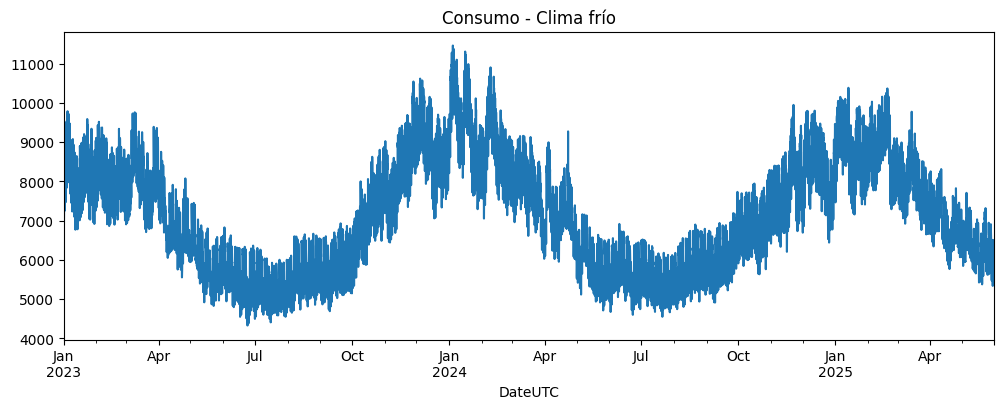

In [ ]:
train_frio['Value'].plot(figsize=(12,4), title="Consumo - Clima frío")

<Axes: title={'center': 'Consumo - Clima frío (Log transformado)'}, xlabel='DateUTC'>

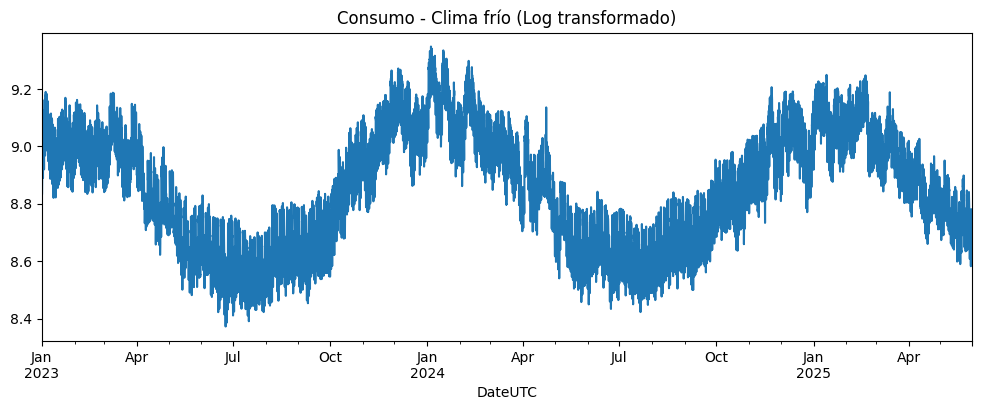

In [ ]:
log_frio = np.log(train_frio['Value'])
log_frio.plot(figsize=(12,4), title="Consumo - Clima frío (Log transformado)")

### **Estacionariedad**



Con el fin de verificar las propiedades estadísticas de la serie, se evaluó su estacionariedad mediante la prueba de Dickey-Fuller aumentada (ADF). Los resultados obtenidos arrojan un p-value de 0.0028, lo cual permite rechazar la hipótesis nula de presencia de raíz unitaria a niveles de significancia convencionales. En consecuencia, se concluye que la serie es estacionaria en media.

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(log_frio.dropna())
print("p-value:", result[1])

p-value: 0.002873485539056704


### **Identificación de modelo por ACF Y PACF**

Con el fin de identificar los posibles órdenes del modelo ARIMA, se analizaron las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) de la serie de consumo energético en clima frío.

La función de autocorrelación (ACF) muestra una disminución lenta y persistente en los coeficientes, lo cual sugiere la presencia de una estructura autorregresiva en la serie. Además, se observa un patrón cíclico claro en la ACF, caracterizado por oscilaciones regulares, lo que indica la existencia de estacionalidad en los datos.

Por su parte, la función de autocorrelación parcial (PACF) presenta coeficientes significativos en los primeros rezagos, especialmente en los primeros dos o tres lags, seguido de una rápida disminución hacia valores cercanos a cero. Este comportamiento es consistente con la presencia de un componente autorregresivo de bajo orden.

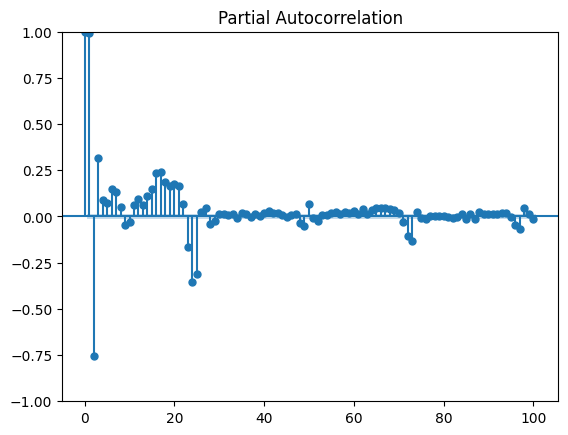

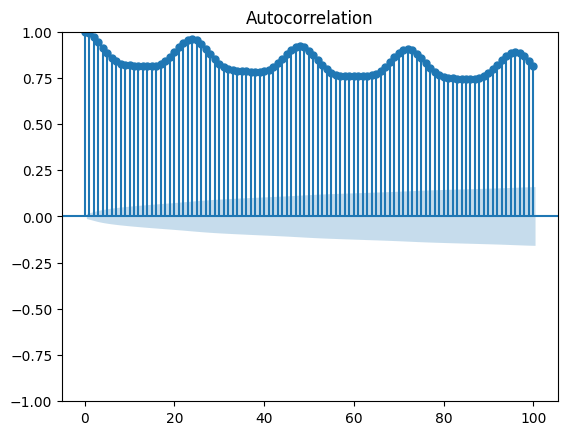

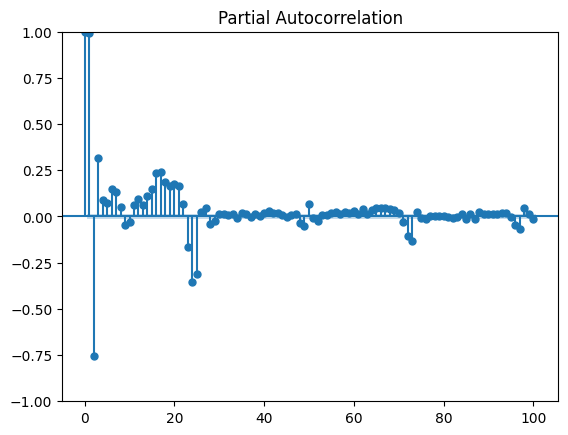

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train_frio['Value'], lags=100)
plot_pacf(train_frio['Value'], lags=100)

Estos resultados sugieren la inclusión de componentes autorregresivos (AR) y de media móvil (MA) en la especificación del modelo. En particular, la evidencia gráfica es consistente con la consideración de órdenes bajos para los parámetros (P y q)
q, lo cual coincide con los resultados obtenidos posteriormente mediante la selección basada en criterios de información y desempeño predictivo.

Adicionalmente, la persistencia observada en la ACF respalda la inclusión de un término de diferenciación (d=1), con el objetivo de capturar posibles componentes de tendencia en la serie.

### **Selección de modelos por AIC Y BIC**

Con el objetivo de seleccionar la especificación más adecuada del modelo ARIMA, se realizó una búsqueda sistemática sobre distintas combinaciones de órdenes
(p,d,q), utilizando el conjunto de entrenamiento.

Para cada combinación, se estimó el modelo correspondiente y se calcularon los criterios de información de Akaike (AIC) y Bayesiano (BIC), los cuales permiten evaluar el balance entre el ajuste del modelo y su complejidad. En ambos casos, valores más bajos indican una mejor especificación.


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# --------------------------------------------------
# 1. Serie (SOLO TRAIN)
# --------------------------------------------------
y_train = log_frio

# --------------------------------------------------
# 2. Inicialización
# --------------------------------------------------
best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None

pq_rng = range(3)
d_rng  = range(2)

# --------------------------------------------------
# 3. Búsqueda
# --------------------------------------------------
for p in pq_rng:
    for d in d_rng:
        for q in pq_rng:
            try:
                model = ARIMA(y_train, order=(p,d,q)).fit()

                # AIC
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order_aic = (p,d,q)

                # BIC
                if model.bic < best_bic:
                    best_bic = model.bic
                    best_order_bic = (p,d,q)

            except:
                continue

# --------------------------------------------------
# 4. Resultados
# --------------------------------------------------
print("Mejor modelo según AIC:", best_order_aic, "AIC:", best_aic)
print("Mejor modelo según BIC:", best_order_bic, "BIC:", best_bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: Conve

Mejor modelo según AIC: (2, 1, 2) AIC: -118606.82266797565
Mejor modelo según BIC: (2, 1, 2) BIC: -118567.02711069422


Los resultados muestran que el modelo **ARIMA(2,1,2)** minimiza tanto el AIC como el BIC, con valores de -118606.82 y -118567.03, respectivamente. Este resultado indica que dicha especificación logra un ajuste adecuado a los datos.


In [ ]:
from sklearn.metrics import mean_squared_error
# --------------------------------------------------
# 1. Definir series
# --------------------------------------------------
y_train = np.log(train_frio['Value'])
y_val   = np.log(val_frio['Value'])

# --------------------------------------------------
# 2. Búsqueda de hiperparámetros
# --------------------------------------------------
best_rmse = np.inf
best_order = None
best_mdl = None

pq_rng = range(3)
d_rng  = range(2)

# --------------------------------------------------
# 3. Grid search
# --------------------------------------------------
for p in pq_rng:
    for d in d_rng:
        for q in pq_rng:
            try:
                model = ARIMA(y_train, order=(p, d, q)).fit()

                # Forecast del tamaño de validation
                forecast_val = model.forecast(steps=len(y_val))

                # Asegurar alineación
                forecast_val.index = y_val.index

                rmse = np.sqrt(mean_squared_error(y_val, forecast_val))

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_order = (p, d, q)
                    best_mdl = model

            except Exception as e:
                continue

# --------------------------------------------------
# 4. Resultado
# --------------------------------------------------
print(f"Mejor (p,d,q): {best_order}")
print(f"RMSE Validation: {best_rmse:.4f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: Conve

Mejor (p,d,q): (2, 1, 2)
RMSE Validation: 0.1576


### **Modelo de suavización exponencial**

/tmp/ipykernel_11548/1780373754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_frio['hour'] = train_frio.index.hour


<Axes: title={'center': 'Perfil diario promedio - clima frío'}, xlabel='hour'>

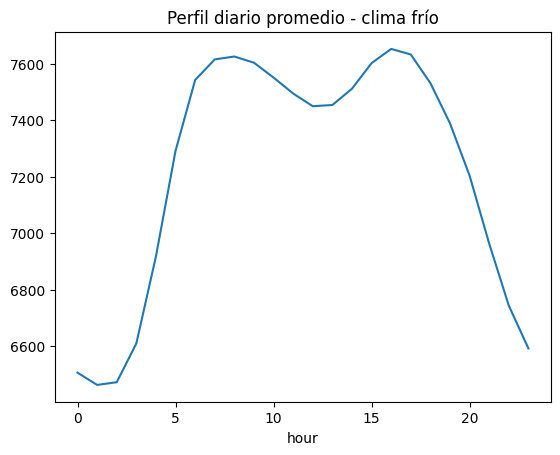

In [ ]:
train_frio['hour'] = train_frio.index.hour

perfil = train_frio.groupby('hour')['Value'].mean()
perfil.plot(title="Perfil diario promedio - clima frío")

Con el objetivo de comparar enfoques alternativos de modelación, se estimaron diferentes variantes de modelos de suavización exponencial sobre la serie de consumo energético en clima frío. En particular, se consideraron tres especificaciones: suavización simple, modelo de Holt y modelo de Holt-Winters.

La suavización exponencial simple modela la serie considerando únicamente un nivel promedio, sin incorporar componentes de tendencia ni estacionalidad. Por su parte, el modelo de Holt extiende esta especificación al incluir un componente de tendencia, permitiendo capturar cambios sistemáticos en el nivel de la serie a lo largo del tiempo. Finalmente, el modelo de Holt-Winters incorpora tanto tendencia como estacionalidad, siendo especialmente adecuado para series con patrones cíclicos, como es el caso del consumo energético con frecuencia horaria.

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

# --------------------------------------------------
# 1. Serie
# --------------------------------------------------
y_train = np.log(train_frio['Value'])
y_val   = np.log(val_frio['Value'])

# --------------------------------------------------
# 2. MODELOS
# --------------------------------------------------

# ┖ 1. Suavización simple
ets_s = ExponentialSmoothing(y_train).fit()
forecast_s = ets_s.forecast(steps=len(y_val))
rmse_s = np.sqrt(mean_squared_error(y_val, forecast_s))

# ┖ 2. Holt (con tendencia)
ets_h = ExponentialSmoothing(
    y_train,
    trend='add'
).fit()
forecast_h = ets_h.forecast(steps=len(y_val))
rmse_h = np.sqrt(mean_squared_error(y_val, forecast_h))

# ┖ 3. Holt-Winters (TENDENCIA + ESTACIONALIDAD DIARIA)
ets_hw = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add',
    seasonal_periods=24
).fit()
forecast_hw = ets_hw.forecast(steps=len(y_val))
rmse_hw = np.sqrt(mean_squared_error(y_val, forecast_hw))

# --------------------------------------------------
# 3. COMPARACIÓN (AIC)
# --------------------------------------------------
print("RMSE Simple:", rmse_s)
print("RMSE Holt:", rmse_h)
print("RMSE Holt-Winters:", rmse_hw)

RMSE Simple: 0.22539787668820235
RMSE Holt: 29.53953126775406
RMSE Holt-Winters: 0.1694043584992741


Con el objetivo de comparar enfoques alternativos de modelación, se estimaron diferentes variantes de modelos de suavización exponencial sobre la serie de consumo energético en clima frío. En particular, se consideraron tres especificaciones: suavización simple, modelo de Holt y modelo de Holt-Winters.

La suavización exponencial simple modela la serie considerando únicamente un nivel promedio, sin incorporar componentes de tendencia ni estacionalidad. Por su parte, el modelo de Holt extiende esta especificación al incluir un componente de tendencia, permitiendo capturar cambios sistemáticos en el nivel de la serie a lo largo del tiempo. Finalmente, el modelo de Holt-Winters incorpora tanto tendencia como estacionalidad, siendo especialmente adecuado para series con patrones cíclicos, como es el caso del consumo energético con frecuencia horaria.

Aunque el modelo Holt-Winters incorpora explícitamente la estacionalidad intradiaria, el modelo ARIMA(2,1,2) presenta un mejor desempeño predictivo en el conjunto de validación. Esto sugiere que, además de los patrones estacionales, la serie de consumo energético está influenciada por dependencias dinámicas de corto plazo y choques transitorios, los cuales son capturados de manera más eficiente por la estructura autorregresiva y de media móvil del modelo ARIMA.

La diferencia relativamente pequeña en los valores de RMSE indica que ambos enfoques son adecuados para modelar la serie; sin embargo, el modelo ARIMA logra una mayor precisión en la predicción.

### **Reentrenar modelo ARIMA con los conjuntos Train y Validation**



Una vez seleccionado el modelo ARIMA(2,1,2), este fue reentrenado utilizando los conjuntos de entrenamiento y validación. Los resultados de la estimación muestran que todos los coeficientes del modelo son estadísticamente significativos, lo que confirma la relevancia de los componentes autorregresivos y de media móvil en la dinámica del consumo energético.

En particular, los coeficientes autorregresivos evidencian una alta persistencia temporal, mientras que los componentes de media móvil capturan la influencia de choques transitorios en la serie. Desde una perspectiva económica, esto sugiere que el consumo energético depende tanto de su comportamiento pasado como de perturbaciones de corto plazo.

In [ ]:
y_full = pd.concat([np.log(train_frio['Value']), np.log(val_frio['Value'])])

model_final = ARIMA(y_full, order=(2,1,2)).fit()
model_final.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Value   No. Observations:                25537
Model:                 ARIMA(2, 1, 2)   Log Likelihood               70273.627
Date:                Wed, 01 Apr 2026   AIC                        -140537.254
Time:                        15:31:17   BIC                        -140496.515
Sample:                    01-01-2023   HQIC                       -140524.081
                         - 11-30-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6519      0.004    398.015      0.000       1.644       1.660
ar.L2         -0.7674      0.004   -193.889      0.000      -0.775      -0.760
ma.L1         -0.8210      0.004   -203.557      0.000      -0.829      -0.813
ma.L2         -0.1117      0.004    -31.702      0.000      -0.119      -0.105
sigma2         0.0002   8.64e-07    275.426      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   6.32   Jarque-Bera (JB):           1754452.94
Prob(Q):                              0.01   Prob(JB):                         0.00
Heteroskedasticity (H):               1.31   Skew:                            -0.86
Prob(H) (two-sided):                  0.00   Kurtosis:                        43.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Una vez seleccionado el modelo ARIMA(2,1,2), este fue reentrenado utilizando los conjuntos de entrenamiento y validación. Los resultados de la estimación muestran que todos los coeficientes del modelo son estadísticamente significativos, lo que confirma la relevancia de los componentes autorregresivos y de media móvil en la dinámica del consumo energético.

En particular, los coeficientes autorregresivos evidencian una alta persistencia temporal, mientras que los componentes de media móvil capturan la influencia de choques transitorios en la serie. Desde una perspectiva económica, esto sugiere que el consumo energético depende tanto de su comportamiento pasado como de perturbaciones de corto plazo.

## **Clima calido**


Siguiendo el esquema aplicado a la serie de países de clima frío, se realiza una transformación logarítmica a la serie de consumo energético de los países con clima cálido, con el objetivo de estabilizar la varianza y reducir la influencia de valores extremos.

En la figura se observa que, aunque la serie mantiene patrones claros de estacionalidad y ciclos en el tiempo, presenta fluctuaciones pronunciadas y algunos picos y caídas abruptas en el consumo. La transformación logarítmica permite suavizar estas variaciones, conservando la dinámica temporal de la serie y facilitando su posterior modelación.

<Axes: title={'center': 'Consumo - Clima calido'}, xlabel='DateUTC'>

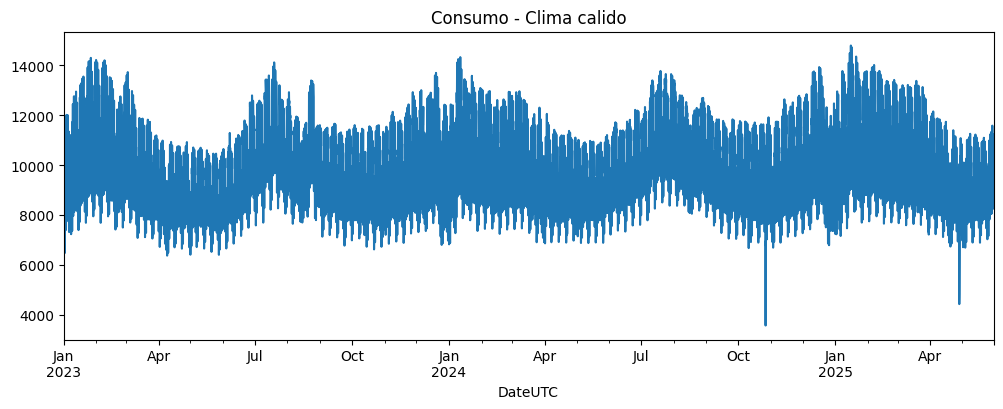

In [ ]:
train_calor['Value'].plot(figsize=(12,4), title="Consumo - Clima calido")

<Axes: title={'center': 'Consumo - Clima calido (Log transformado)'}, xlabel='DateUTC'>

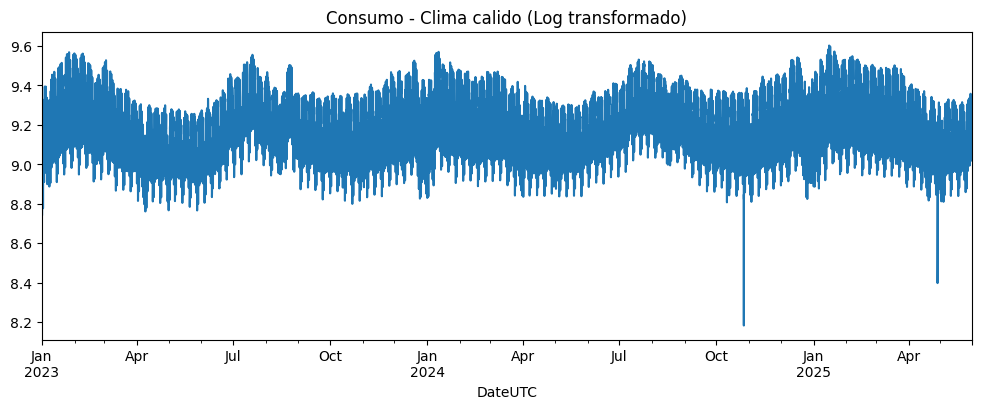

In [ ]:
log_calido = np.log(train_calor['Value'])
log_calido.plot(figsize=(12,4), title="Consumo - Clima calido (Log transformado)")

### **Estacionariedad**

Con el fin de evaluar las propiedades estadísticas de la serie de consumo energético en países de clima cálido, se aplicó la prueba de Dickey-Fuller aumentada (ADF) sobre la serie transformada en logaritmos.

El resultado obtenido arroja un p-value menor a 0.001, lo cual es significativamente menor a los niveles de significancia convencionales. En consecuencia, se rechaza de manera contundente la hipótesis nula de presencia de raíz unitaria, indicando que la serie es estacionaria en media.

Este resultado sugiere que la dinámica del consumo energético en climas cálidos presenta una estructura más estable en el tiempo, sin evidencia de tendencias estocásticas persistentes.

In [ ]:
result = adfuller(log_calido.dropna())
print("p-value:", result[1])

p-value: 1.5333195765864091e-22


### **Identificación de modelo por ACF y PACF**

Siguiendo el proceso de modelación, se analizan las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) de la serie transformada con el fin de identificar la estructura del modelo.

En la figura se observa que la ACF presenta un patrón claramente estacional, con picos significativos y repetitivos en ciertos rezagos, lo que sugiere la presencia de estacionalidad en la serie. Por su parte, la PACF muestra un corte más pronunciado en los primeros rezagos, seguido de valores cercanos a cero, lo que indica la posible presencia de componentes autorregresivos de bajo orden.

En conjunto, estos patrones sugieren que la serie puede ser modelada mediante un proceso que incorpore tanto componentes autorregresivos como estacionales.

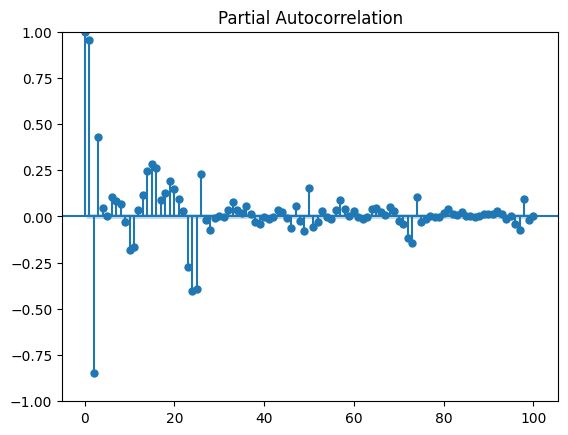

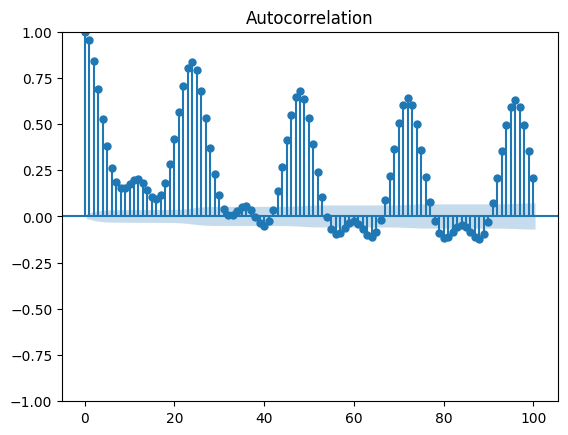

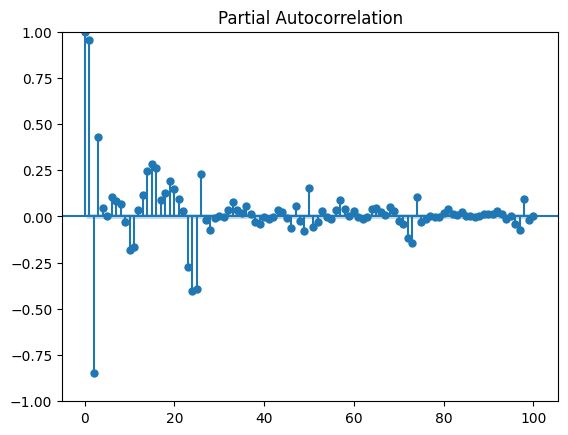

In [ ]:
plot_acf(train_calor['Value'], lags=100)
plot_pacf(train_calor['Value'], lags=100)

### **Selección de modelos por AIC y BIC**

Con el objetivo de identificar la mejor especificación del modelo ARIMA para la serie de consumo energético en países de clima cálido, se realizó una búsqueda sistemática sobre distintas combinaciones de órdenes (p,d,q), utilizando el conjunto de entrenamiento.

Los resultados obtenidos indican que el modelo ARIMA(2,1,2) minimiza tanto el AIC como el BIC, lo que sugiere que esta especificación ofrece el mejor balance entre ajuste y parsimonia para la serie analizada.


In [ ]:
# --------------------------------------------------
# 1. Serie (SOLO TRAIN)
# --------------------------------------------------
y_train = log_calido

# --------------------------------------------------
# 2. Inicialización
# --------------------------------------------------
best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None

pq_rng = range(3)
d_rng  = range(2)

# --------------------------------------------------
# 3. Búsqueda
# --------------------------------------------------
for p in pq_rng:
    for d in d_rng:
        for q in pq_rng:
            try:
                model = ARIMA(y_train, order=(p,d,q)).fit()

                # AIC
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order_aic = (p,d,q)

                # BIC
                if model.bic < best_bic:
                    best_bic = model.bic
                    best_order_bic = (p,d,q)

            except:
                continue

# --------------------------------------------------
# 4. Resultados
# --------------------------------------------------
print("Mejor modelo según AIC:", best_order_aic, "AIC:", best_aic)
print("Mejor modelo según BIC:", best_order_bic, "BIC:", best_bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: Conve

Mejor modelo según AIC: (2, 1, 2) AIC: -96600.01812755493
Mejor modelo según BIC: (2, 1, 2) BIC: -96560.2225702735


Los resultados obtenidos indican que el modelo ARIMA(2,1,2) minimiza tanto el AIC como el BIC, lo que sugiere que esta especificación ofrece el mejor balance entre ajuste y parsimonia para la serie analizada.

### RMSE ARIMA

In [ ]:
# --------------------------------------------------
# 1. Definir series
# --------------------------------------------------
y_train = np.log(train_calor['Value'])
y_val   = np.log(val_calor['Value'])

# --------------------------------------------------
# 2. Búsqueda de hiperparámetros
# --------------------------------------------------
best_rmse = np.inf
best_order = None
best_mdl = None

pq_rng = range(3)
d_rng  = range(2)

# --------------------------------------------------
# 3. Grid search
# --------------------------------------------------
for p in pq_rng:
    for d in d_rng:
        for q in pq_rng:
            try:
                model = ARIMA(y_train, order=(p, d, q)).fit()

                # Forecast del tamaño de validation
                forecast_val = model.forecast(steps=len(y_val))

                # Asegurar alineación
                forecast_val.index = y_val.index

                rmse = np.sqrt(mean_squared_error(y_val, forecast_val))

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_order = (p, d, q)
                    best_mdl = model

            except Exception as e:
                continue

# --------------------------------------------------
# 4. Resultado
# --------------------------------------------------
print(f"Mejor (p,d,q): {best_order}")
print(f"RMSE Validation: {best_rmse:.4f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: Conve

Mejor (p,d,q): (2, 1, 2)
RMSE Validation: 0.1546


### **Modelo de suavización exponencial**

/tmp/ipykernel_11548/1984350730.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_calor['hour'] = train_calor.index.hour


<Axes: title={'center': 'Perfil diario promedio - clima calido'}, xlabel='hour'>

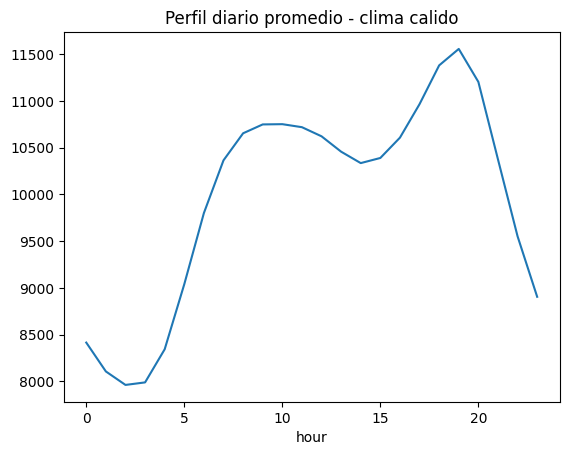

In [ ]:
train_calor['hour'] = train_calor.index.hour

perfil = train_calor.groupby('hour')['Value'].mean()
perfil.plot(title="Perfil diario promedio - clima calido")

Se estimaron distintas variantes de modelos de suavización exponencial sobre el conjunto de entrenamiento. En particular, se consideraron tres especificaciones: suavización exponencial simple, modelo de Holt y modelo de Holt-Winters.

se estimaron distintas variantes de modelos de suavización exponencial sobre el conjunto de entrenamiento. En particular, se consideraron tres especificaciones: suavización exponencial simple, modelo de Holt y modelo de Holt-Winters.

In [ ]:
# --------------------------------------------------
# 1. Serie
# --------------------------------------------------
y_train = np.log(train_calor['Value'])
y_val   = np.log(val_calor['Value'])

# --------------------------------------------------
# 2. MODELOS
# --------------------------------------------------

# ┖ 1. Suavización simple
ets_s = ExponentialSmoothing(y_train).fit()
forecast_s = ets_s.forecast(steps=len(y_val))
rmse_s = np.sqrt(mean_squared_error(y_val, forecast_s))

# ┖ 2. Holt (con tendencia)
ets_h = ExponentialSmoothing(
    y_train,
    trend='add'
).fit()
forecast_h = ets_h.forecast(steps=len(y_val))
rmse_h = np.sqrt(mean_squared_error(y_val, forecast_h))

# ┖ 3. Holt-Winters (TENDENCIA + ESTACIONALIDAD DIARIA)
ets_hw = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add',
    seasonal_periods=24
).fit()
forecast_hw = ets_hw.forecast(steps=len(y_val))
rmse_hw = np.sqrt(mean_squared_error(y_val, forecast_hw))

# --------------------------------------------------
# 3. COMPARACIÓN (AIC)
# --------------------------------------------------
print("RMSE Simple:", rmse_s)
print("RMSE Holt:", rmse_h)
print("RMSE Holt-Winters:", rmse_hw)

RMSE Simple: 0.23918781180140508
RMSE Holt: 126.24341624400053
RMSE Holt-Winters: 0.12088133511957291


A diferencia del caso de climas fríos, donde el modelo ARIMA presentó un mejor desempeño, en climas cálidos el modelo Holt-Winters resulta superior.
Este resultado indica que en climas cálidos el consumo energético sigue patrones más regulares y predecibles a lo largo del día, lo cual favorece el uso de modelos que capturan explícitamente la estacionalidad, como Holt-Winters.


### **Reentrenar modelo Holt-Winter con los conjuntos Train y Validation**

Una vez seleccionado el modelo Holt-Winters, este fue reentrenado utilizando los conjuntos de entrenamiento y validación. Los resultados muestran que los parámetros de suavización para el nivel y la tendencia (𝛼=1, 𝛽=1) toman valores elevados, lo que indica que el modelo otorga un peso significativo a las observaciones más recientes, reflejando una alta capacidad de adaptación a cambios de corto plazo.

Por otro lado, el parámetro de estacionalidad (𝛾≈0) sugiere que los patrones estacionales son altamente estables en el tiempo, lo cual es consistente con la presencia de ciclos diarios bien definidos en el consumo energético en climas cálidos.

In [ ]:
y_full = pd.concat([train_calor['Value'], val_calor['Value']])
ets_final = ExponentialSmoothing(
    y_full,
    trend='add',
    seasonal='add',
    seasonal_periods=24
).fit()
ets_final.summary()

Dep. Variable:,Value,No. Observations:,25537
Model:,ExponentialSmoothing,SSE,935523174.616
Optimized:,True,AIC,268417.510
Trend:,Additive,BIC,268645.651
Seasonal:,Additive,AICC,268417.583
Seasonal Periods:,24,Date:,"Wed, 01 Apr 2026"
Box-Cox:,False,Time:,16:25:44
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,1.0000000,beta,True


Adicionalmente, los componentes estacionales estimados permiten identificar variaciones sistemáticas a lo largo del día, evidenciando menores niveles de consumo durante la madrugada y mayores niveles en horas de alta demanda. Esto confirma la importancia de la estacionalidad intradiaria en la dinámica del consumo energético